In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost
    
    

In [ ]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        # raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        legal_actions = []

        for action, move_coordinate in MOVES.items():
            row, col = state
            change_in_row, change_in_col = move_coordinate
            neighbour = (row + change_in_row, col + change_in_col)

            if self.in_bounds(neighbour) and self.is_free(neighbour):
                legal_actions.append(action)

        return legal_actions
        # raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        row, col = state
        change_in_row, change_in_col = MOVES[action]
        return (row + change_in_row, col + change_in_col)
        # raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1.0
        # raise NotImplementedError("Complete GridProblem.action_cost")

In [ ]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [ ]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [ ]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

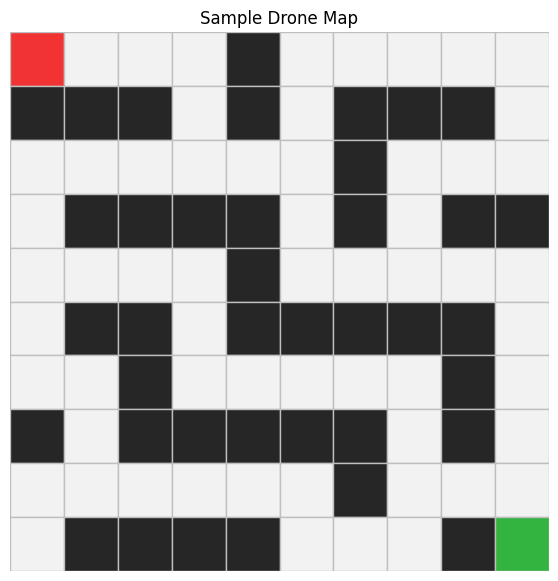

In [ ]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        state = node.state
        
        for action in problem.actions(state):
          state_prime = problem.result(state, action)
          cost = node.path_cost + problem.action_cost(state, action, state_prime)
          
          yield Node(state_prime, node, action, cost)
          

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(problem.initial_state())
        
        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_frontier_size = 1
        
        # 2. If the initial state is the goal, return successs.
        if problem.is_goal(initial_node.state):
          return SearchResult(algorithm, "success", initial_node, nodes_expanded, max_frontier_size)
        
        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])
        
        # 4. Create a reached set and add the initial state.
        reached = {initial_node.state}
        
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        while frontier:
          node = frontier.popleft()
          nodes_expanded += 1
          
        # d. for each child:
          for child in self.expand(problem, node):
            if problem.is_goal(child.state):
        #     i. if child is goal, return success.
              return SearchResult(algorithm, "success", child, nodes_expanded, max_frontier_size)
        #     ii. if child.state is not in reached:
            if child.state not in reached:
          #   add child.state to reached.
              reached.add(child.state)
          #   append child to frontier.
              frontier.append(child)
            
        # e. update max_frontier_size.
          max_frontier_size = max(max_frontier_size, len(frontier))   
                 
        # 6. Return failure if no solution is found.
        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size)
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
       
        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(problem.initial_state())
        
        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_frontier_size = 1
        
        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
            return SearchResult(algorithm, "success", initial_node, nodes_expanded, max_frontier_size)
               
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        
        # 4. Use a reached set.
        reached = {initial_node.state}
        
        # 5. While frontier is not empty:
        while frontier:
        #       a. pop from the end of the list.
            node = frontier.pop()
        #       b. increment nodes_expanded.
            nodes_expanded += 1
        #       c. expand the node.
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(algorithm, "success", child, nodes_expanded, max_frontier_size)
                
        #       d. add unreached children to the stack.
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                
        #   e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        
        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size)
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        # raise NotImplementedError("Complete DepthFirstSearch.search")

In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return (node, "success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "cutoff")
        # 3. Otherwise:
        else:
        #   a. increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] += 1

        #   b. set cutoff_occurred = False.
            cutoff_occurred = False

        #   c. for each child in expand(problem, node):
            for child in self.expand(problem, node):
        #       i. skip the child if child.state already appears on the current path.
                if state_is_on_path(node, child.state):
                    continue
        #       ii. update max_stack_size.
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
                    
        #       iii. recursively call _recursive_dls on the child.
                result_node, result_status = self._recursive_dls(problem=problem, node=child, limit=limit, metrics=metrics, current_stack_size=current_stack_size + 1)
                
        #       iv. if result is "success", return success immediately.
                if result_status ==  "success":
                    return (result_node, "success")
                
        #       v. if result is "cutoff", set cutoff_occurred = True.
                if result_status == "cutoff":
                    cutoff_occurred = True
        
        #   d. after all children:
        #      if cutoff_occurred, return (None, "cutoff")
            if cutoff_occurred:
                return (None, "cutoff")

        #   else return (None, "failure")
            return (None, "failure")
        # raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        iteration_log = []

        # Initialize tracking metrics required for the final SearchResult
        nodes_expanded = 0
        max_stack_size = 0

        # 2. Accumulate total nodes expanded across all DLS iterations.
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)

            nodes_expanded += result.nodes_expanded

            # 3. Track the maximum stack size seen in any DLS run.
            max_stack_size = max(
                max_stack_size,
                result.max_frontier_size
            )

            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "solution_depth": result.solution_depth,
                "solution_cost": result.solution_cost,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            })

            # 4. If a DLS run returns success, return a SearchResult for IDS.
            if result.status == "success":
                return SearchResult(algorithm=algorithm, status="success", solution=result.solution, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=limit, iterations=iteration_log,
                )

            # 5. If a DLS run returns failure, IDS can stop early and return failure.
            if result.status == "failure":
                return SearchResult(algorithm=algorithm, status="failure", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=limit, iterations=iteration_log,
                )

        # 6. If all limits return cutoff up to max_depth, return cutoff.
        return SearchResult(algorithm=algorithm, status="cutoff", solution=None, nodes_expanded=nodes_expanded, max_frontier_size=max_stack_size, reached_count=0, limit=max_depth, iterations=iteration_log,
        )

        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

In [ ]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,18,4,0
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


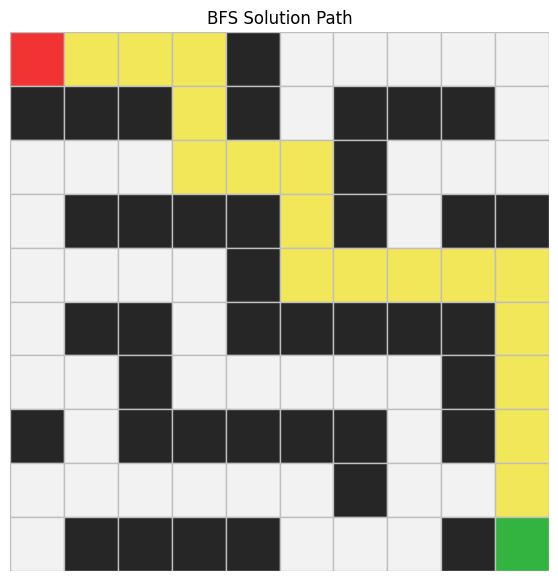

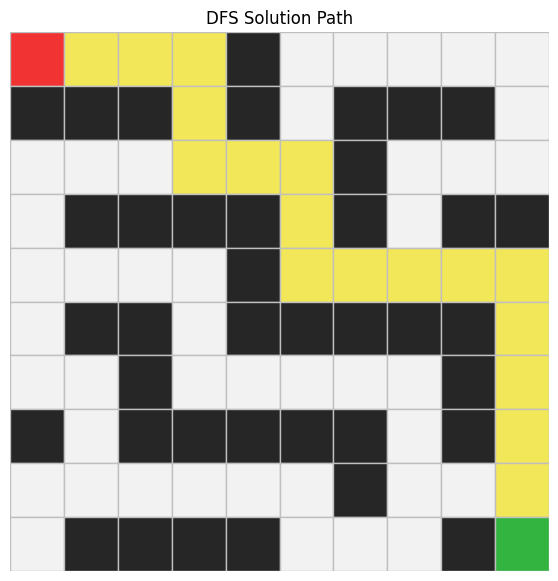

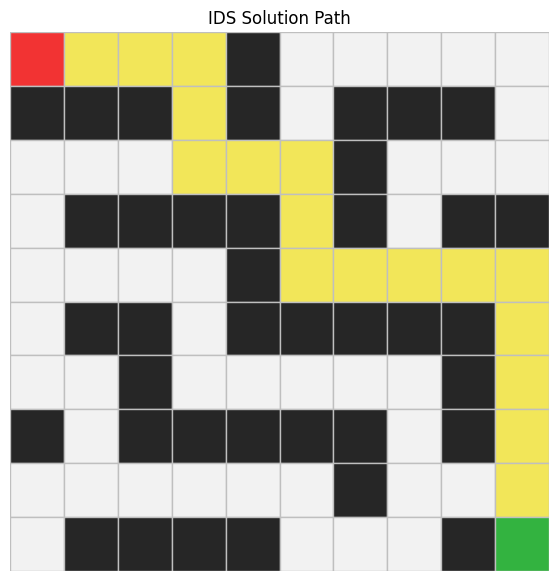

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]
ids_result = results[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)


plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="IDS Solution Path",
)



In [ ]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]    
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 10)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28.0,28.0,73,8,0
1,DFS,success,NaN,32.0,32.0,32,6,0
2,DLS,cutoff,20.0,NaN,NaN,72,21,0
3,IDS,success,28.0,28.0,28.0,1383,29,0


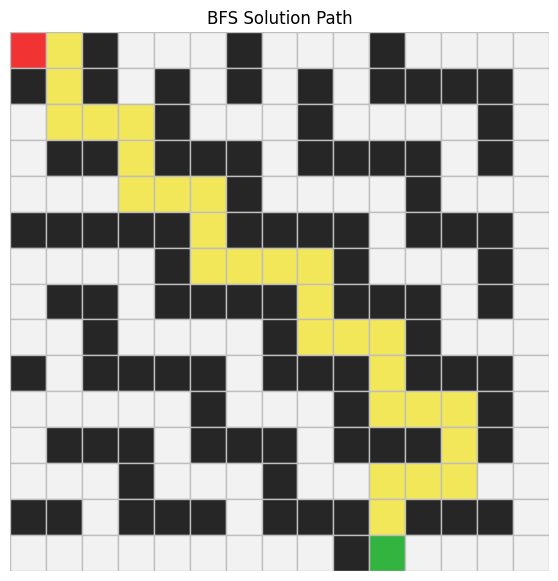

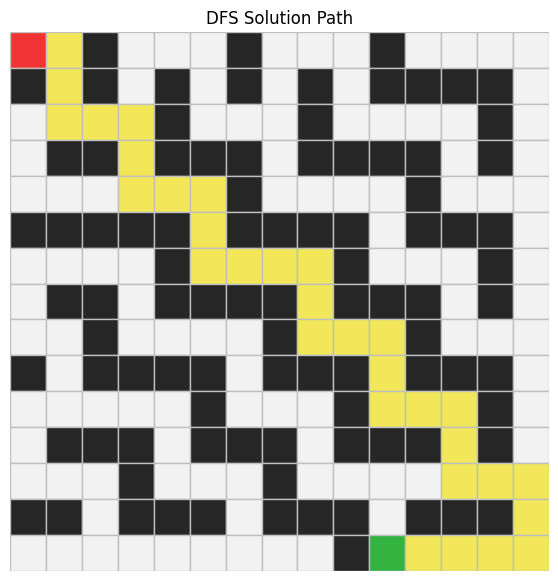

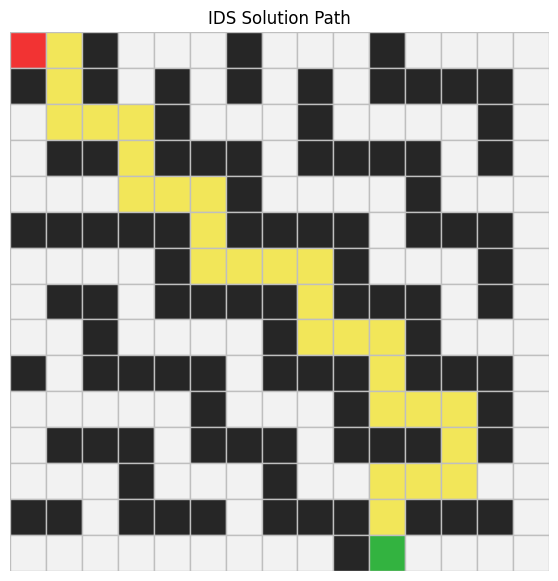

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
ids_result = custom_results_1[3]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="DFS Solution Path",
)


plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=ids_result.path,
    title="IDS Solution Path",
)



The first custom map is a 15×15 maze containing multiple branches and dead ends. BFS found an optimal solution with depth 28 and cost 28 after expanding 73 nodes. DFS found a valid solution after expanding only 32 nodes, but the solution depth was 32, which is longer than the BFS solution. This occurred because DFS followed a branch near the goal that led to a longer route before reaching the destination. DLS with a limit of 20 returned a cutoff because the solution depth exceeded the search limit. IDS eventually found the optimal solution at depth 28 but required significantly more node expansions due to repeated depth-limited searches.

In [ ]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0]
]

custom_start_2 = (2, 0)
custom_goal_2 = (19, 7)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,36.0,36.0,220,14,0
1,DFS,success,NaN,50.0,50.0,50,10,0
2,DLS,cutoff,20.0,NaN,NaN,83,21,0
3,IDS,success,36.0,36.0,36.0,3121,37,0


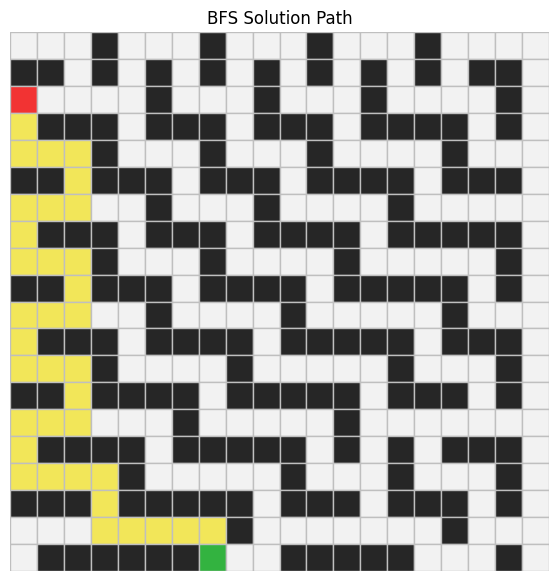

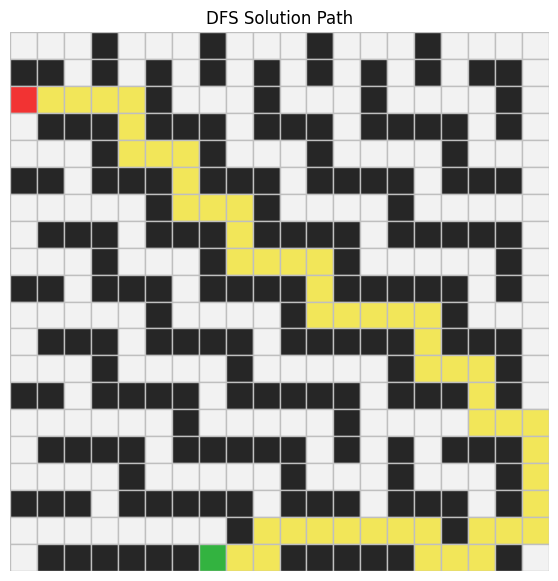

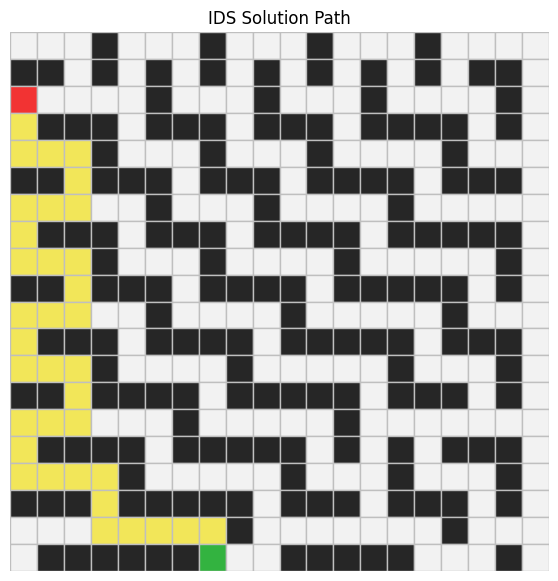

In [ ]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]
ids_result = custom_results_2[3]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",
)


plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=ids_result.path,
    title="IDS Solution Path",
)

BFS found the shortest path with a solution depth of 36 and expanded 220 nodes, confirming that it guarantees optimal solutions by exploring level by level. DFS also reached the goal but produced a longer path of depth 50, showing that it does not guarantee optimality even though it may expand fewer nodes. DLS failed to find a solution within the depth limit of 20, indicating that the limit was too small for this problem. IDS found the optimal solution with depth 36, matching BFS, but required significantly more node expansions (3121) due to repeated searches at increasing depth limits. Overall, BFS and IDS are optimal, DFS is faster but suboptimal, and DLS is highly dependent on the chosen limit.

### **Reflection Questions**

**What is a state in this lab?**

A state represents the current position of the agent on the grid. It is stored as a tuple in the form (row, col), where row and column indicate the agent's location. An example is, (4, 1) means the agent is at fifth row and second column.


**What is an action?**

An actions is any legal action the actuator of an agent can perform. In a grid problem, we have only "RIGHT", "LEFT", "UP" and "DOWN" as the legal moves of the agent. An action can only be taken if it ensures the agent does not move into an obstacle or go out of the grid.

**What does the result function do?**

The result function returns the new state obtained after applying a legal action to the current state. For example, applying "LEFT" to (1, 3) would produce (1, 2) if that move is legal. It tells the current agent, there is a change of environment after an action is taken.

**Why is it useful to separate the problem definition from the search algorithm?**

Separating the problem from the search algorithm makes the code more reusable. Otherwise for each problem, a search algorithm must be written which causes code duplication and disk inefficiency, so the same search algorithm can be utilized on many different problem while only the problem-specific functions need to change. This is a good software design principles.






**BFS**

**Why does BFS use a FIFO queue?**

A FIFO (First-In, First-Out) queue ensures that the oldest node is expanded first. This allows BFS to search level by level. BFS explores nodes in the order they were discovered. Hence FIFO Queue becomes the best data structure to store the frontiers.

**Why does BFS find the shortest path in terms of number of steps on the unweighted grid?**

BFS explores all states at first depth before second depth, all states at the second depth before the third one, and so on. Therefore, the first time the goal is found, it must be at the smallest possible depth. Since all moves have equal cost, this corresponds to the shortest path in terms of steps.

**What role does the reached set play in BFS?**

The reached set keeps track of states that have already been visited. This prevents the algorithm from revisiting the same state repeatedly. It also improves efficiency by avoiding unnecessary expansions of frontiers or nodes.

**DFS**

**Why does DFS use a stack?**

A stack is Last-In, First-Out (LIFO) principled data structure, which naturally supports this behavior of the DFS. DFS explores the most recently discovered node first. This causes DFS to follow one path as deeply as possible before backtracking.

**Is DFS guaranteed to find the shortest path? Explain.**

In the experiments, DFS often found a longer path than BFS. So no, DFS is not guaranteed to find the shortest path. It returns the first solution it encounters, which may be deeper than the optimal solution.

**Under what conditions can DFS use less memory than BFS?**

DFS only stores the current path and a small number of unexplored nodes. BFS must store all frontier nodes at the current depth level. Therefore, DFS generally uses less memory when the search space is very large.

**Under what conditions can DFS perform badly?**

DFS can perform poorly when there are long incorrect paths. It may spend a lot of time exploring branches that are not productive before reaching the goal. This can lead to longer solution times and non-optimal solutions.

**DLS**

**What happens when the depth limit is too small?**

If the depth limit is smaller than the depth of the goal, DLS cannot reach the goal. The search stops when the limit is reached, even if a solution exists deeper in the search tree.

**What is the meaning of "cutoff"?**

A cutoff means the search stopped because it reached the depth limit. It does not necessarily mean that no solution exists. It only means that the search was unable to look deeper.

**How is DLS different from ordinary DFS?**

DLS is DFS only that it has a maximum depth restriction. Ordinary DFS can continue indefinitely in deep search spaces, while DLS stops once the specified depth limit is reached. This helps control the search depth.

**Why do we use path-cycle checking in DLS?**

Because of the existence of recursive searches in DLS, path-cycle checking prevents the search from revisiting states already on the current path. Without it, the algorithm could repeatedly move in loops and waste time.

**IDS**

**Why does IDS repeat DLS with increasing limits?**

IDS gradually increases the depth limit so that it can search deeper levels over time. This allows it to find shallow solutions first while eventually reaching deeper solutions if necessary.

**Why can IDS be complete even though DLS with a small limit is not?**

A single DLS may fail because its limit is too small. IDS overcomes this by repeatedly increasing the limit until the goal depth is reached. As a result, IDS will eventually find a solution if one exists.

**Why does IDS use less memory than BFS?**

IDS performs depth-first searches, which require storing only the current search path. BFS must store every frontier node at each level. Therefore, IDS has memory requirements similar to DFS and much lower than BFS.

**What is the cost of repeatedly searching from the root?**

It just causes repeated work, since nodes near the root are expanded multiple times in different iterations. This increases the total number of node expansions compared to BFS.

**Real-World Drone Context**

**In a real drone application, what might make one route safer or more practical than another?**

A route may be safer if it avoids obstacles, bad weather, restricted airspace, or areas with signal interference. It may also be more practical if it consumes less battery power which also depends on the route, or reduces flight time.

**Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.**

Even though it is not memory efficient, I would go with BFS because it guarantees the shortest path in terms of the number of moves when all actions have equal cost. It goes through states level by level and finds the shallowest solution.

**Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.**

I would choose DLS because it allows a maximum depth limit to be specified. This ensures the search does not explore beyond a predetermined depth, making it useful when search resources are limited.

**What limitations does this grid model have compared with real drone navigation?**

In the grid problem, it is noticed that the legal actions are just in four directions which over simplifies the problem space. Real drones operate in continuous 3D space and also moves in any angle it wants including diagonal, and must consider factors such as altitude, weather conditions, battery constraints, and dynamic obstacles. Therefore, the grid model does not fully capture the complexity of real-world navigation.